In [124]:

import sys
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


data = np.load("../../../_recordings/2024-06-09--11-45-43-Z_7-with-<P>^2/archive.npz")



results = {}

for experiment in data.keys():
    experiment_parameters = data[experiment]["reboot_seed"]["experiment_parameters"][0]
    shape = experiment_parameters["shape"]

    if shape[0] in results:
        results[shape[0]].append(data[experiment])
    else:
        results[shape[0]] = [data[experiment]]

z_order = 7
roots_of_unity = np.array([[np.cos(2 * np.pi * i / z_order),
                                np.sin(2 * np.pi * i / z_order)] for i in range(z_order)])



lattice_sizes = []

result_keys = list(results.keys())
result_keys.sort()


time_series = {}
tin_data = {}
pp_correlators = {}
average_plaquettes = {}

for shape in result_keys:
    results[shape].sort(key=lambda x: x["reboot_seed"]["experiment_parameters"]["beta"])

    print(shape)
    for res in results[shape]:
        print(res.dtype)


    results[shape] = np.array(results[shape])

    

    rec_shape = results[shape]["ploop_corr_recordings"]["polyakov_loops"].shape

    _,_,number_rec, x_dim, y_dim, z_dim = rec_shape


    loops = results[shape]["ploop_corr_recordings"]["polyakov_loops"]
    loops = roots_of_unity[loops]

    # Tin Data
    temp = loops.sum(axis=(3,4,5))
    tin_snapshot = np.linalg.norm(temp, axis=-1)  
    tin_snapshot = tin_snapshot.sum(axis=(1,2))/(number_rec*x_dim*y_dim*z_dim)
    tin_data[x_dim]= tin_snapshot

    # Time series
    time_serie = loops.sum(axis=(3,4,5)).squeeze(axis=1)/(x_dim*y_dim*z_dim)
    time_series[x_dim] = time_serie

    betas = results[shape]["reboot_seed"]["experiment_parameters"]["beta"].squeeze()

    lattice_sizes.append(x_dim)

    pp_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators"]
    average_plaquettes[x_dim] = results[shape]["ploop_corr_recordings"]["average_plaquette"]


 


# save the data
np.savez("temp/treated_data", time_series=time_series, tin_data=tin_data, betas=betas, lattice_sizes=lattice_sizes, pp_correlators=pp_correlators, average_plaquettes=average_plaquettes)
    



6
[('reboot_seed', [('last_state', [('edges', 'u1', (5184,)), ('rng_gen', [('rng_gen_wrapper', 'u1', (16,))]), ('performed_updates', '<u8'), ('accepted_updates', '<u8')]), ('experiment_parameters', [('shape', '<u4', (4,)), ('z_order', '<u4'), ('beta', '<f4'), ('lambda', '<f4'), ('rng_seed', '<u8')])]), ('run_info', [('recordings', '<u4'), ('recording_skip', '<u4'), ('recordings_until_backup', '<u4'), ('backup_number', '<u4'), ('recording_time', '<i8'), ('run_id', '<u4')]), ('ploop_corr_recordings', [('polyakov_loops', 'u1', (100000, 6, 6, 6)), ('polyakov_loop_correlators', '<f4', (100000, 7, 2)), ('pp_correlators', '<f4', (100000, 7, 2)), ('average_plaquette', '<f4', (100000, 2))])]
[('reboot_seed', [('last_state', [('edges', 'u1', (5184,)), ('rng_gen', [('rng_gen_wrapper', 'u1', (16,))]), ('performed_updates', '<u8'), ('accepted_updates', '<u8')]), ('experiment_parameters', [('shape', '<u4', (4,)), ('z_order', '<u4'), ('beta', '<f4'), ('lambda', '<f4'), ('rng_seed', '<u8')])]), ('run_

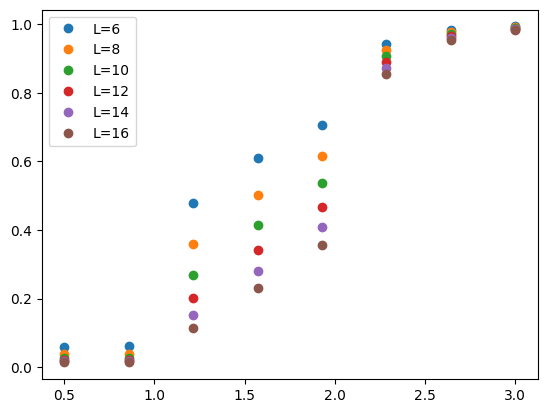

In [133]:
data = np.load("temp/treated_data.npz", allow_pickle=True)

tin_data = data["tin_data"].item()
betas = data["betas"]

fig, ax = plt.subplots()

for key in tin_data.keys():
    ax.plot(betas, tin_data[key], 'o', label=f"L={key}")

ax.legend()
plt.show()

6 (8, 100000, 2)
8 (8, 100000, 2)
10 (8, 72000, 2)
12 (8, 33000, 2)
14 (8, 17000, 2)
16 (8, 9000, 2)


/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


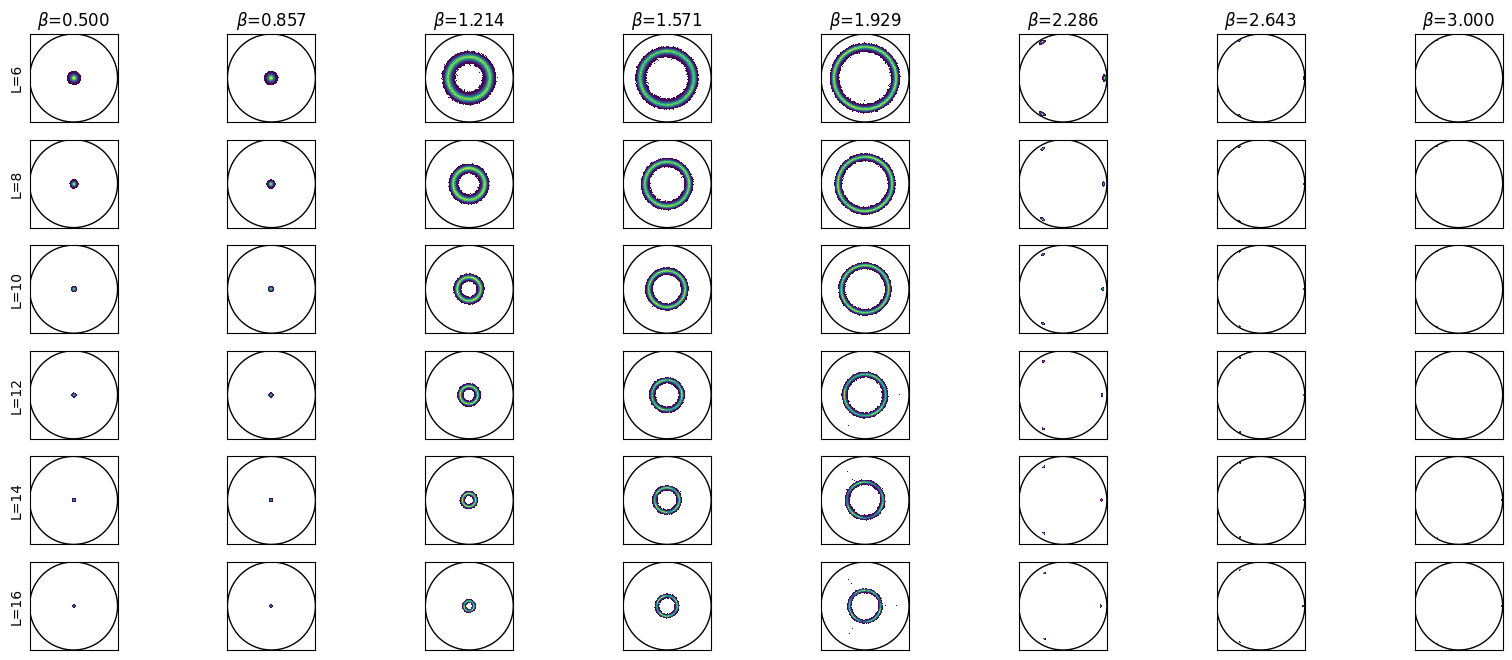

In [134]:

data = np.load("temp/treated_data.npz", allow_pickle=True)

time_series = data["time_series"].item()

betas = data["betas"]


for key in time_series.keys():
    print(key, time_series[key].shape)

# Give number of keys in the dictionary
num_lattice_sizes = len(time_series.keys())


rows = num_lattice_sizes
columns = len(betas)


fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(rows, columns)

axes = []

white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

# for i in range(rows):
for (i, key) in enumerate(time_series.keys()):
    for j in range(columns):
        time_serie = time_series[key][j]
        time_serie_rotated = time_serie.copy()
        rotation_matrix = np.array([[np.cos(2 * np.pi / 3), -np.sin(2 * np.pi / 3)], [
                                    np.sin(2 * np.pi / 3), np.cos(2 * np.pi / 3)]])

        time_serie_rotated = np.dot(time_serie, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        time_serie_rotated = np.dot(time_serie_rotated, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        x = time_serie[:, 0]
        y = time_serie[:, 1]

        radius = 1

        axes.append(fig.add_subplot(
            gs[i, j], projection='scatter_density'))

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].scatter_density(x, y, cmap=white_viridis, dpi=200)

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].set_aspect('equal', 'box')
        axes[-1].set_xticks([])
        axes[-1].set_yticks([])
        # axes[-1].set_title(f"{index}")
        circle = plt.Circle((0, 0), 1, color='black', fill=False)
        axes[-1].add_artist(circle)


for i in range(columns):
    axes[i].set_title(r"$\beta$={:.3f}".format(
        betas[i]))

# Add title to rows
for i in range(rows):
    axes[i*columns].set_ylabel(f"L={lattice_sizes[i]}")

plt.show()


(9000, 17, 2)


/var/folders/85/yh7sv5kx12nfh8mkhfkgjrt40000gn/T/ipykernel_64444/681234336.py:52: RuntimeWarning: divide by zero encountered in divide
  plt.plot(Ls-1, (scale)**2/(Ls**2) - plateau, '--', color='red')


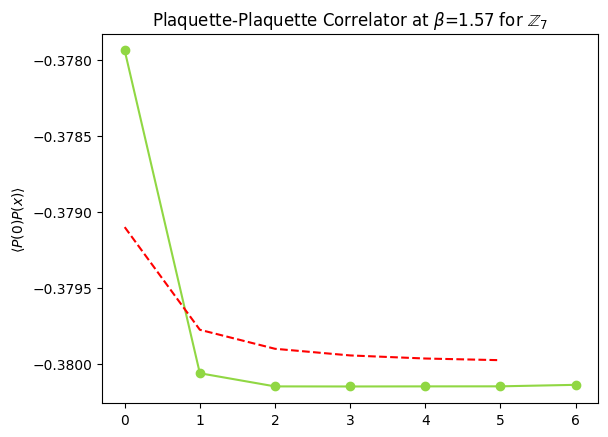

In [135]:
data = np.load("temp/treated_data.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()

fig = plt.figure()



# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=0, vmax=len(pp_correlators.keys()))


which_beta = 3

for (i,key) in enumerate(pp_correlators.keys()):

    if key != 16:
        continue

    pp_correlator = pp_correlators[key][which_beta,:,...].squeeze(axis=0)

    print(pp_correlator.shape)

    color = cmap(norm(i))

    pp_correlator_mean = pp_correlator.mean(axis=0)[:,0]

    cutoff = 1
    if cutoff > 0:
        pp_correlator_mean = pp_correlator_mean[cutoff:-cutoff]
    else: 
        pp_correlator_mean = pp_correlator_mean

    M = len(pp_correlator_mean)
    pp_correlator_mean = pp_correlator_mean[:M//2]

    data = np.log(pp_correlator_mean)

    Ls = np.arange(len(pp_correlator_mean))
    max_L = np.max(Ls)
    # Ls = Ls / max_L

    # Ls = 1/Ls

    # log_of_pp_correlator_mean = np.log(-np.log(pp_correlator_mean))

    plt.plot(Ls, data, '-o', label=f"L={key}", color=color)

    scale = 0.03
    plateau = 0.380

    plt.plot(Ls-1, (scale)**2/(Ls**2) - plateau, '--', color='red')

    #plot error bars
    #calculate variance
    variance = pp_correlator.var(axis=0)[:,0]
    variance = variance[cutoff:-cutoff]
    std = np.sqrt(variance/len(pp_correlator))


    # plt.fill_between(Ls, pp_correlator_mean-std, pp_correlator_mean+std, alpha=0.4, color=color)
    #also plot bars 
    # plt.errorbar(Ls, pp_correlator_mean, yerr=std, fmt='o', color=color)


# plt.xticks([])

#log log plot
# plt.xscale("log")
# plt.yscale("log")

plt.ylabel(r"$\langle P(0)P(x)\rangle$")

plt.title(r"Plaquette-Plaquette Correlator at $\beta$=1.57 for $\mathbb{Z}_7$")
# plt.legend()

plt.savefig("pp_correlator.pdf")

# change the ylim
# plt.ylim(-0.968, -0.967)


plt.show()


(8, 1, 100000, 7, 2)
(8, 1, 100000, 9, 2)
(8, 1, 72000, 11, 2)
(8, 1, 33000, 13, 2)
(8, 1, 17000, 15, 2)
(8, 1, 9000, 17, 2)


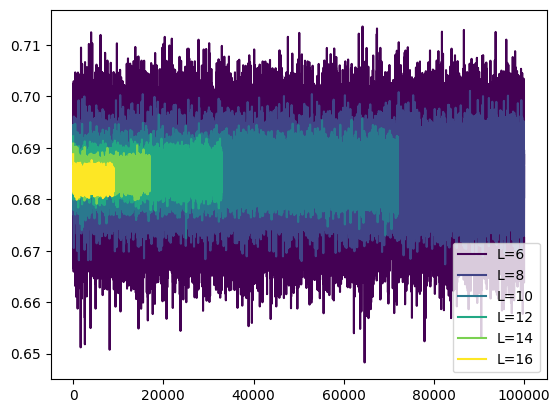

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

data = np.load("temp/treated_data.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()

fig = plt.figure()

which_beta = 3

# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=6, vmax=16)



for key in pp_correlators.keys():
    print(pp_correlators[key].shape)

    pp_correlator = pp_correlators[key][which_beta,:,...].squeeze(axis=0)

    lattice_size = 2
    time_series = pp_correlator

    time_series = time_series[:,lattice_size,0]

    time_series = time_series[1:]

    xs = np.arange(len(time_series))

    color = cmap(norm(key))

    plt.plot(xs[1:], time_series[1:], '-', label=f"L={key}", color=color)

plt.legend()
plt.show()


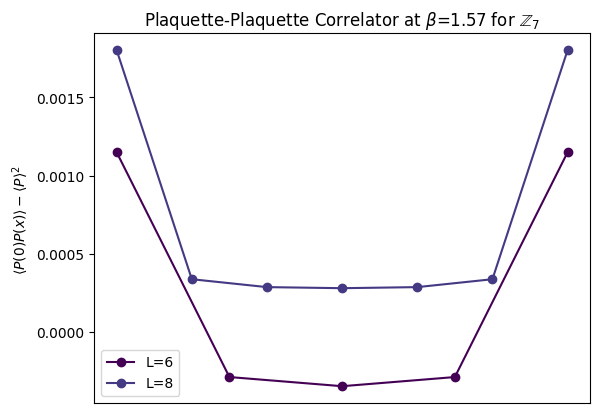

In [291]:

data = np.load("temp/treated_data.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()
average_plaquettes = data["average_plaquettes"].item()



fig = plt.figure()



# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=0, vmax=len(pp_correlators.keys()))


which_beta = 3

for (i,key) in enumerate(pp_correlators.keys()):

    if key != 6 and key != 8: 
        continue


    pp_correlator = pp_correlators[key][which_beta,:,...].squeeze(axis=0)
    average_plaquette = average_plaquettes[key][which_beta,:,...].squeeze(axis=0)

    color = cmap(norm(i))

    thermalise = 0
    # end = 10000


    pp_correlator_mean = pp_correlator[thermalise:].mean(axis=0)[:]
    average_plaquette_mean = average_plaquette[thermalise:].mean(axis=0)



    pp_correlator_mean = pp_correlator_mean[:,0]
    average_plaquette_mean = average_plaquette_mean[0]



    cutoff = 1
    if cutoff > 0:
        pp_correlator_mean = pp_correlator_mean[cutoff:-cutoff]
    else: 
        pp_correlator_mean = pp_correlator_mean




    pp_correlator_mean = pp_correlator_mean - average_plaquette_mean**2



    Ls = np.arange(len(pp_correlator_mean))
    max_L = np.max(Ls)
    Ls = Ls / max_L

    plt.plot(Ls, pp_correlator_mean, '-o', label=f"L={key}", color=color)

    #plot error bars
    #calculate variance
    variance = pp_correlator.var(axis=0)[:,0]
    variance = variance[cutoff:-cutoff]
    std = np.sqrt(variance/len(pp_correlator))


    # plt.fill_between(Ls, pp_correlator_mean-std, pp_correlator_mean+std, alpha=0.4, color=color)
    # #also plot bars 
    # plt.errorbar(Ls, pp_correlator_mean, yerr=std, fmt='o', color=color)


plt.xticks([])
plt.ylabel(r"$\langle P(0)P(x)\rangle - \langle P \rangle^2$ ")

plt.title(r"Plaquette-Plaquette Correlator at $\beta$=1.57 for $\mathbb{Z}_7$")
plt.legend()

plt.savefig("pp_correlator.pdf")


plt.show()


6
0.68417865
0.82736087


8
0.6844944
0.82717276


10
0.68496305
0.82732147


12
0.6851071
0.82757074


14
0.68470573
0.8276891


16
0.68376034
0.8277567




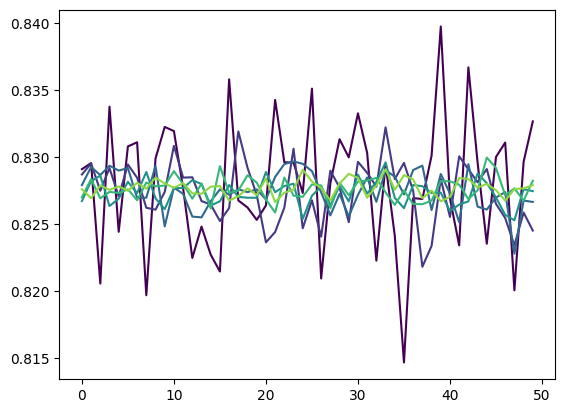

In [140]:
data = np.load("temp/treated_data.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()
average_plaquettes = data["average_plaquettes"].item()

fig = plt.figure()



# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=0, vmax=len(pp_correlators.keys()))


which_beta = 3

middle_points = []

for (i,key) in enumerate(pp_correlators.keys()):
  

    pp_correlator = pp_correlators[key][which_beta,:,...].squeeze(axis=0)
    average_plaquette = average_plaquettes[key][which_beta,:,...].squeeze(axis=0)

    color = cmap(norm(i))

    #res = pp_correlator[:,pp_correlator.shape[1]//2,0] #- average_plaquette[:,0]**2
    res =  average_plaquette[:,0]

    print(key)
    print(pp_correlator.mean(axis=0)[:,0][pp_correlator.shape[1]//2])
    print(average_plaquette.mean(axis=0)[0])
    print("\n")


    middle_points.append(res)


# plot the middle points
for (i, m) in enumerate(middle_points):
    zoom = 50

    L = 100

    m = m[2:][zoom:L]
    x = np.arange(len(m))
    color = cmap(norm(i))

    plt.plot(x, m, '-', label=f"L={lattice_sizes[i]}", color=color)


6
(100000,)


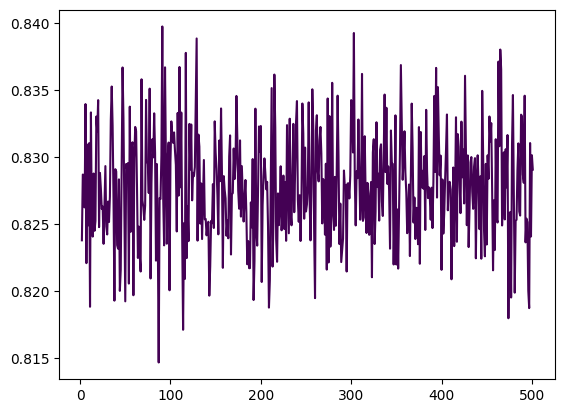

In [173]:
data = np.load("temp/treated_data.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()
average_plaquettes = data["average_plaquettes"].item()


cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=6, vmax=16)

which_beta = 3

for (i,key) in enumerate(pp_correlators.keys()):
    
    if key != 6:
        continue

    zoom = 500
    start = 2

    pp_correlator = pp_correlators[key][which_beta,:,...].squeeze(axis=0)
    average_plaquette = average_plaquettes[key][which_beta,:,...].squeeze(axis=0)[:,0]

    print(key)
    print(average_plaquette.shape)

    xs = np.arange(len(average_plaquette))

    color = cmap(norm(key))

    plt.plot(xs[start : start + zoom], average_plaquette[start : start + zoom], '-', label=f"L={key}", color=color)




In [274]:
folder_names = ["../../../_recordings/2024-06-09--11-45-43-Z_7-with-<P>^2/7-L_6_6_6_6-b_2p64-l_0p00",
"../../../_recordings/2024-06-09--11-45-43-Z_7-with-<P>^2/15-L_8_8_8_8-b_2p64-l_0p00",
"../../../_recordings/2024-06-09--11-45-43-Z_7-with-<P>^2/23-L_10_10_10_10-b_2p64-l_0p00",
"../../../_recordings/2024-06-09--11-45-43-Z_7-with-<P>^2/31-L_12_12_12_12-b_2p64-l_0p00",
"../../../_recordings/2024-06-09--11-45-43-Z_7-with-<P>^2/39-L_14_14_14_14-b_2p64-l_0p00",
"../../../_recordings/2024-06-09--11-45-43-Z_7-with-<P>^2/47-L_16_16_16_16-b_2p64-l_0p00"]

# iterate trhough the files

import os

for folder_name in folder_names:
    files = os.listdir(folder_name)

    pp_mean = 0
    counter = 0
    average_mean = 0


    for file_ in files:
        data = np.load(folder_name + "/" + file_)
        # print(data['ploop_corr_recordings']['pp_correlators'].shape)

        pp_correlator = data['ploop_corr_recordings']['pp_correlators'][0,:,3,0]
        average_plaquette = data['ploop_corr_recordings']['average_plaquette'][0,:,0]

        for pp in pp_correlator:
            pp_mean += pp
            counter += 1

        for av in average_plaquette:
            average_mean += av
        
    pp_mean = pp_mean/counter
    average_mean = average_mean/counter

    print(average_mean)
        
    




0.9896120958530903
0.9896063089168071
0.9896251061093317
0.9896422073985591
0.9896475862054264
0.9896547968056467
